# 07 — Injection point, feasibility, and delegation uncertainty

This notebook gathers the injection-point, feasibility-oracle, search-budget,
and delegation-uncertainty analyses. It is self-contained given the repository's
`data/` directory and the shared modules `guardrail_core.py`,
`experiment_core.py`, and `experiment_core_v2.py`.

Contents
1. Environment & data
2. **Separating the injection point from the fallback** — the
   injection×fallback factorial under a matched search budget, on both the
   confirmed (n=155) and all-predicted (n=363) cohorts.
3. **Rejection-sampling feasibility oracle** — an optimiser-free
   check that the admissible region is non-empty.
4. **Feasibility curve over search budget**.
5. **Violation taxonomy** with explicit candidate- vs patient-level
   denominators.
6. **LLM tier uncertainty** — bootstrap CIs and effect sizes.

All heavy cohort loops are cached to `results/tables/*.csv`; the cells below
load those caches and render the summary tables and figure. To regenerate the
caches from scratch, run the standalone scripts noted in each section.

## 1. Environment & data

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, joblib
import numpy as np, pandas as pd
os.environ["TQDM_DISABLE"] = "1"

import guardrail_core as gc
import experiment_core_v2 as ec2

DATA = "../data"; TAB = "../results/tables"
ac = joblib.load(f"{DATA}/agent_config.pkl")
X, T, VARY = ac["X_features"], ac["target_col"], ac["vary_features"]
print("Features:", X)
print("Target:", T)
print("Delegated (varying) features:", VARY)

Features: ['BMI', 'WaistCirc', 'Weight', 'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg', 'Fat_g', 'SaturatedFat_g', 'Fiber_g', 'Potassium_mg', 'Protein_g', 'ObesityStatus', 'WeightChangeStatus', 'WeightLossAmount', 'WeightGainAmount', 'DrinkingFrequency', 'DrinkingAmount', 'SmokingStatus', 'VigorousActivity_Work', 'VigorousActivity_Leisure', 'ModerateActivity_Work', 'WalkingActivity', 'AerobicActivityRate', 'BreakfastFrequency', 'StressLevel', 'StressAwarenessRate', 'PersonalIncomeQuartile', 'HouseholdIncomeQuartile', 'EducationLevel', 'HealthScreeningStatus']
Target: RiskClass
Delegated (varying) features: ['BMI', 'WaistCirc', 'Weight', 'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg', 'Fat_g', 'SaturatedFat_g', 'Fiber_g', 'Potassium_mg', 'Protein_g', 'ObesityStatus', 'WeightChangeStatus', 'WeightLossAmount', 'WeightGainAmount', 'DrinkingFrequency', 'DrinkingAmount', 'SmokingStatus', 'VigorousActivity_Work', 'VigorousActivity_Leisure', 'ModerateActivity_Work', 'WalkingActivity', 'Aero

In [2]:
# cohort sizes
for g, code_ in [("male", 1.0), ("female", 2.0)]:
    m = joblib.load(f"{DATA}/model_{g}.pkl"); v = joblib.load(f"{DATA}/val_{g}.pkl")
    pred = m.predict(v["X_val"])
    conf = ((v["y_val"] == 3) & (pred == 3)).sum()
    print(f"{g:6s}: predicted Class 3 = {(pred==3).sum():3d} | "
          f"true & predicted (confirmed) = {conf:3d}")

male  : predicted Class 3 = 182 | true & predicted (confirmed) =  89


female: predicted Class 3 = 181 | true & predicted (confirmed) =  66


## 2. Separating the injection point from the fallback

The original comparison paired post-hoc filtering (C1) with an unconstrained
target and no fallback, against pre-injection (C2) with a 0→1→2 stepwise
fallback. That confounds *where* the admissible region is imposed with the
fallback. Here we vary the two factors **independently** under a matched search
budget (identical `total_CFs`, retries, target schedule, and seed).

The full 363-patient loop is produced by `run_cohort.py` and cached to
`results/tables/cohort.csv`; we load it and summarise.

In [3]:
d = pd.read_csv(f"{TAB}/cohort.csv")
conf = d[d.confirmed]; alll = d
COND = ["C0_pure","C1_post_nofb","C1b_post_fb","C2a_pre_nofb","C2_pre_fb"]
LAB = {"C0_pure":"C0 unconstrained","C1_post_nofb":"C1 post-hoc, no fallback",
       "C1b_post_fb":"C1b post-hoc, +fallback","C2a_pre_nofb":"C2a pre-inject, no fallback",
       "C2_pre_fb":"C2 pre-inject, +fallback"}

def feas(df): return df.groupby("cond")["feasible"].mean().reindex(COND)
tbl = pd.DataFrame({"Confirmed (n=155)": feas(conf), "All predicted (n=363)": feas(alll)})
tbl.index = [LAB[c] for c in tbl.index]
(tbl*100).round(1)

,Confirmed (n=155),All predicted (n=363)
C0 unconstrained,100.0,100.0
"C1 post-hoc, no fallback",0.0,0.0
"C1b post-hoc, +fallback",0.6,0.3
"C2a pre-inject, no fallback",95.5,96.4
"C2 pre-inject, +fallback",99.4,99.2


**Reading:** post-hoc filtering stays at ~0% whether or not fallback is on;
pre-injection stays near-ceiling whether or not fallback is on. The gap tracks
the injection point, not the fallback, and is nearly identical on the
all-predicted cohort — so it is not an artefact of conditioning on correct
predictions ( #5).

## 3. Rejection-sampling feasibility oracle

In [4]:
# fraction of patients for whom a uniform draw inside the admissible band
# lands in a target class -> the admissible region is non-empty.
oracle = d.drop_duplicates("pid")["rs_feasible"].mean()
print(f"Rejection-sampling oracle: admissible solution found for "
      f"{oracle*100:.1f}% of patients")
print("=> the post-hoc collapse is a search-placement failure, "
      "not an empty feasible set.")

Rejection-sampling oracle: admissible solution found for 98.6% of patients
=> the post-hoc collapse is a search-placement failure, not an empty feasible set.


## 4. Feasibility curve over search budget

Produced by `run_feasibility_curve.py` (cached to
`results/tables/feasibility_curve.csv`). Post-hoc feasibility does not improve
as the candidate budget grows, while pre-injection is at ceiling throughout.

In [5]:
fc = pd.read_csv(f"{TAB}/feasibility_curve.csv")
dice = fc[fc.scheme.isin(["posthoc","preinjection"])]
curve = dice.groupby(["scheme","budget"])["feasible"].mean().unstack(0)
(curve*100).round(1)

scheme,posthoc,preinjection
budget,,
2,2.0,100.0
4,2.0,100.0
8,2.0,100.0
16,0.0,100.0


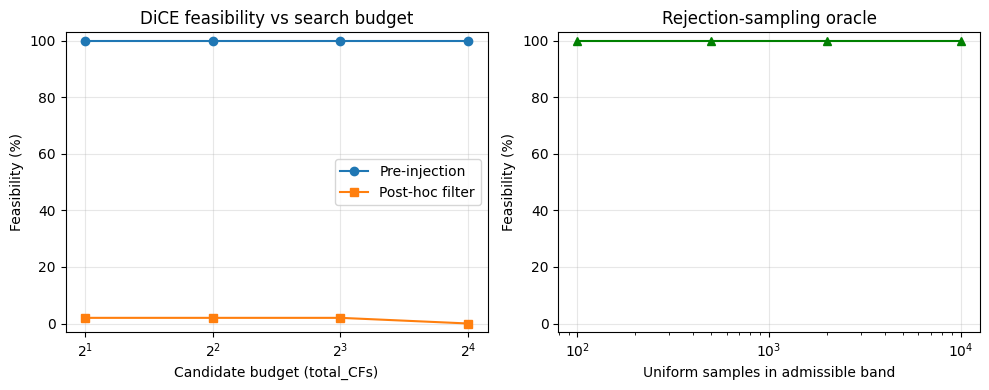

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
rej = fc[fc.scheme=="rejection"].groupby("budget")["feasible"].mean()
fig, ax = plt.subplots(1, 2, figsize=(10,4))
for sch, lab, mk in [("preinjection","Pre-injection","o"),("posthoc","Post-hoc filter","s")]:
    s = dice[dice.scheme==sch].groupby("budget")["feasible"].mean()
    ax[0].plot(s.index, s.values*100, marker=mk, label=lab)
ax[0].set_xscale("log", base=2); ax[0].set_xlabel("Candidate budget (total_CFs)")
ax[0].set_ylabel("Feasibility (%)"); ax[0].set_ylim(-3,103)
ax[0].set_title("DiCE feasibility vs search budget"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(rej.index, rej.values*100, marker="^", color="green")
ax[1].set_xscale("log"); ax[1].set_xlabel("Uniform samples in admissible band")
ax[1].set_ylabel("Feasibility (%)"); ax[1].set_ylim(-3,103)
ax[1].set_title("Rejection-sampling oracle"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Violation taxonomy — candidate vs patient denominators

The mechanism analysis says *every* unconstrained (C0) candidate violates at
least one constraint, while the quality table reports patient-level "any
violation" near 90%. These use different denominators.

In [7]:
c0 = conf[(conf.cond=="C0_pure") & (conf.feasible)]
print("CANDIDATE-LEVEL (denominator = generated candidates):")
print(f"  any violation           : {c0['frac_cands_viol'].mean()*100:5.1f}%")
for k in ["direction","coupling","floor","range"]:
    print(f"  {k:22s}: {c0[k+'_viol'].mean()*100:5.1f}%")
print("PATIENT-LEVEL (denominator = patients):")
print(f"  >=1 violating candidate : {c0['any_viol'].mean()*100:5.1f}%")
print("\nA post-hoc filter needs a FULLY admissible candidate, so the "
      "candidate-level\nnear-total violation is what drives feasibility to zero.")

CANDIDATE-LEVEL (denominator = generated candidates):
  any violation           : 100.0%
  direction             :  92.2%
  coupling              :  80.0%
  floor                 :  37.8%
  range                 :   0.8%
PATIENT-LEVEL (denominator = patients):
  >=1 violating candidate : 100.0%

A post-hoc filter needs a FULLY admissible candidate, so the candidate-level
near-total violation is what drives feasibility to zero.


## 6. LLM tier uncertainty — bootstrap CIs & effect sizes

Produced by `run_llm_uncertainty.py` from the cached per-patient IoU/breach
data (no new API calls). Reported as 95% patient-level bootstrap CIs
(B=10,000) with Cohen's d_z, replacing the earlier p-values.

In [8]:
unc = pd.read_csv(f"{TAB}/llm_tier_uncertainty.csv")
show = unc.assign(
    IoU=lambda r: r.iou_mean.round(3).astype(str)+" ["+r.iou_lo.round(3).astype(str)+", "+r.iou_hi.round(3).astype(str)+"]",
    dz_vs_identity=lambda r: r.iou_dz_vs_identity.round(2),
    breaches=lambda r: r.breach_mean.round(2).astype(str)+" ["+r.breach_lo.round(2).astype(str)+", "+r.breach_hi.round(2).astype(str)+"]",
)[["tier","model","IoU","dz_vs_identity","breaches"]]
show

,tier,model,IoU,dz_vs_identity,breaches
0,weak,gpt-4o-mini,"0.429 [0.413, 0.446]",-5.34,"0.52 [0.36, 0.68]"
1,mid,gpt-5.4-mini,"0.376 [0.364, 0.388]",-8.20,"0.3 [0.19, 0.42]"
2,strong,gpt-5.4,"0.402 [0.389, 0.414]",-7.71,"0.37 [0.26, 0.5]"


In [9]:
pair = pd.read_csv(f"{TAB}/llm_tier_pairwise.csv")
pair.assign(diff=lambda r: r.diff_mean.round(3).astype(str)+" ["+r.diff_lo.round(3).astype(str)+", "+r.diff_hi.round(3).astype(str)+"]",
            dz=lambda r: r.dz.round(2))[["contrast","diff","dz","n_pairs"]]

,contrast,diff,dz,n_pairs
0,weak-mid,"0.054 [0.036, 0.071]",0.48,155
1,weak-strong,"0.028 [0.009, 0.046]",0.24,155
2,mid-strong,"-0.026 [-0.041, -0.011]",-0.28,155


**Reading:** every tier's IoU interval sits far from the identity value 1
(large negative d_z), so the LLM robustly does *not* reproduce the rule. The
pairwise contrasts all exclude zero (the non-monotonicity is real) but are
small-to-moderate in magnitude.

---
*Modules and scripts: `experiment_core_v2.py`, `run_cohort.py`,
`build_tables.py`, `run_feasibility_curve.py`,
`run_llm_uncertainty.py`. *